# 🌾 CropNexus — Notebook 2: Feature Engineering, Preprocessing & Feature Selection

This notebook prepares the cleaned data for machine learning. We do this because models need numeric, well-scaled, well-labeled data to learn properly.

## Import Libraries & Load Cleaned Data
We load the cleaned data saved from Notebook 1 so we can keep building on it without repeating the earlier steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", palette="Set2")
df = pd.read_csv("../data/processed/crop_understood.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 7. Feature Engineering
We create a few new features from the existing ones because extra, meaningful combinations (like nutrient ratios) can help the model make better predictions.

In [2]:
df["npk_sum"] = df["N"] + df["P"] + df["K"]
df["n_p_ratio"] = df["N"] / (df["P"] + 1e-6)
df["n_k_ratio"] = df["N"] / (df["K"] + 1e-6)
df["temp_humidity_index"] = df["temperature"] * df["humidity"] / 100

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall",
            "npk_sum", "n_p_ratio", "n_k_ratio", "temp_humidity_index"]
TARGET = "label"
df[FEATURES + [TARGET]].head()

,N,P,K,temperature,humidity,ph,rainfall,npk_sum,n_p_ratio,n_k_ratio,temp_humidity_index,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,175,2.142857,2.093023,17.121963,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,184,1.465517,2.073171,17.485957,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,159,1.090909,1.363636,18.937446,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,149,2.114286,1.850000,21.234829,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,162,1.857143,1.857143,16.427204,rice


## 8. Data Preprocessing
We turn the crop names into numbers and scale the features because most ML models only work with numeric input, and scaling keeps every feature on a fair playing field.

In [3]:
le = LabelEncoder()
y = le.fit_transform(df[TARGET])
X = df[FEATURES]

print("Classes:", list(le.classes_))
print("X shape:", X.shape, "| y shape:", y.shape)

Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
X shape: (2200, 11) | y shape: (2200,)


In [4]:
scaler = StandardScaler()
X_scaled_preview = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)
X_scaled_preview.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
N,-1.033517e-16,1.000227,-1.369636,2.423483
P,5.167584e-17,1.000227,-1.466498,2.778707
K,-5.167584e-17,1.000227,-0.852136,3.097591
temperature,3.875688e-16,1.000227,-3.316592,3.567190
humidity,-1.808654e-16,1.000227,-2.570842,1.280400
ph,-1.291896e-16,1.000227,-3.831577,4.478912
rainfall,1.550275e-16,1.000227,-1.515170,3.550701
npk_sum,-5.167584e-17,1.000227,-1.690398,2.915330
n_p_ratio,1.033517e-16,1.000227,-0.661429,8.589376
n_k_ratio,-8.397323e-17,1.000227,-1.108363,5.084085


## 9. Feature Selection
We check which features matter most so we only keep the ones that actually help the model, instead of guessing.

/tmp/ipykernel_624/1120817992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="YlGn_r")


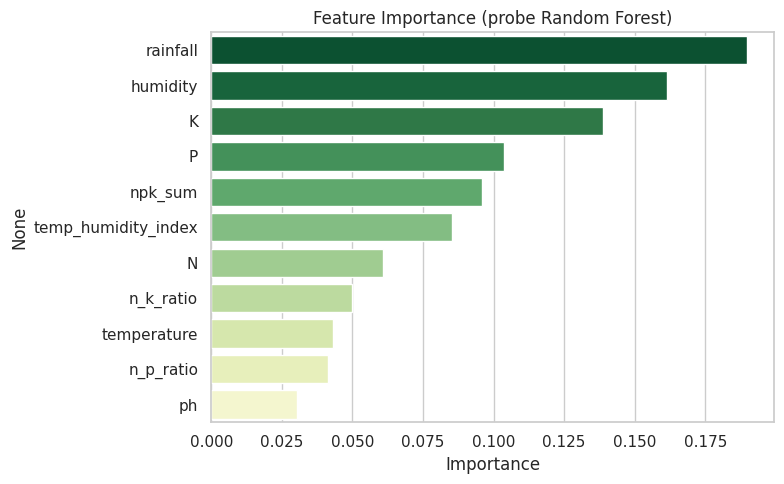

rainfall               0.189844
humidity               0.161516
K                      0.138641
P                      0.103826
npk_sum                0.095837
temp_humidity_index    0.085280
N                      0.060723
n_k_ratio              0.049733
temperature            0.042970
n_p_ratio              0.041289
ph                     0.030342
dtype: float64

In [5]:
rf_probe = RandomForestClassifier(n_estimators=200, random_state=42)
rf_probe.fit(X, y)

importance = pd.Series(rf_probe.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, palette="YlGn_r")
plt.title("Feature Importance (probe Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../data/processed/feature_importance_probe.png", dpi=110)
plt.show()
importance

All 11 features add useful information (none are near-zero), so we keep the full feature set for modelling.

## 10. Train-Test Split
We split the data into train and test sets so we can check how well the model performs on data it has never seen before.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (1760, 11) | Test shape: (440, 11)


In [7]:
import joblib, os
os.makedirs("../data/processed", exist_ok=True)
X_train.assign(label=le.inverse_transform(y_train)).to_csv("../data/processed/train.csv", index=False)
X_test.assign(label=le.inverse_transform(y_test)).to_csv("../data/processed/test.csv", index=False)
joblib.dump(scaler, "../data/processed/_scaler_preview.joblib")
joblib.dump(le, "../data/processed/_label_encoder_preview.joblib")
print("Saved processed train/test splits.")

Saved processed train/test splits.
